# How TokenPath works — a hands-on cookbook

**TokenPath** maps spans of an LLM's answer to source spans using attention
measured by an open model after generation, on *any* model's output. The result
is token-level citation coordinates on both the answer and the document.

This notebook is mostly code. We'll:
1. call the API and watch attention become a citation,
2. do three things string/keyword matching can't (cross-lingual, paraphrase, tables),
3. *(optional, guarded)* inspect the same attention values with raw 🤗
   Transformers on Llama-3.1-8B-Instruct — this walkthrough's pinned reference
   model,
4. and review citation benchmark results and what attribution measures.

The core idea: evaluating an answer with its document produces attention weights
between answer tokens and document tokens. TokenPath reads those weights and rolls
them up into source citations, post-hoc and model-agnostically. It is an
attention-derived attribution measurement.

> The hosted API reads an open reference model that we upgrade over time, so your
> API outputs may differ slightly from the saved ones (last refreshed 2026-07-15
> against the current API). The raw-Transformers section is pinned to
> Llama-3.1-8B-Instruct and reproduces exactly.

## Setup

The API sections need only a free `TOKENPATH_API_KEY` — get one at
[platform.tokenpath.ai](https://platform.tokenpath.ai) (10M attributed tokens on
signup, no card). The optional local-model section (§3) is behind a guard flag.

In [ ]:
%pip install -q requests numpy matplotlib

In [1]:
import os, re
import numpy as np
import requests

BASE = "https://api.tokenpath.ai"
API_KEY = os.environ.get("TOKENPATH_API_KEY")
assert API_KEY, "Set TOKENPATH_API_KEY (free at https://platform.tokenpath.ai)"
AUTH = {"Authorization": f"Bearer {API_KEY}"}

def heatmap(document, question, answer):
    """Raw attention: a sparse answer-token x document-token matrix."""
    r = requests.post(f"{BASE}/v1/attributions/heatmap", headers=AUTH,
                      json={"document": document, "question": question, "answer": answer})
    r.raise_for_status()
    return r.json()

## 1. From attention to a citation

Call the heatmap endpoint on a small document. The Oregon Duck's *color* fact
lives in a sentence that says **"The mascot"**, not "the Oregon Duck" — a
coreference that trips up keyword/embedding search. Let's see where attention
goes.

In [2]:
document = ("The Oregon Duck is the mascot of the University of Oregon. "
            "It is based on Disney's Donald Duck. "
            "The mascot wears a green and yellow costume and a green beanie cap. "
            "The costume was redesigned in 2002.")
question = "What colors does the Oregon Duck wear?"
answer   = "The Oregon Duck wears green and yellow."

h = heatmap(document, question, answer)
print("shape [answer_tokens, document_tokens]:", h["shape"])
print("non-zero attention entries:", len(h["data"]))

shape [answer_tokens, document_tokens]: [8, 46]
non-zero attention entries: 174


The response is sparse (`row`, `col`, `data`) plus character offsets for every
answer and document token. Densify it and take a look at the raw matrix — each row
is an answer token, each column a document token, brighter = more attention.

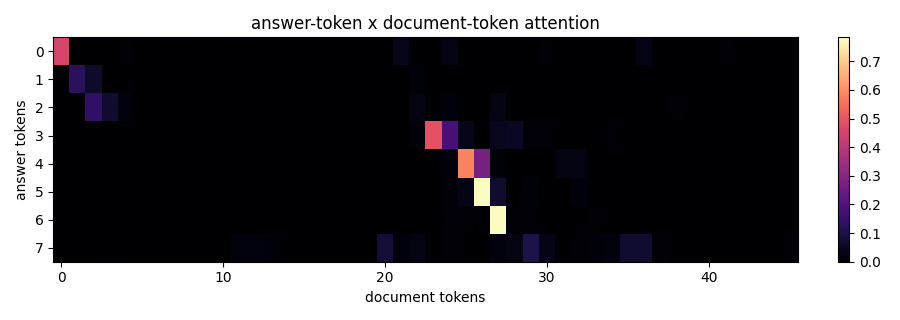

In [3]:
import matplotlib.pyplot as plt

M = np.zeros(h["shape"]); M[h["row"], h["col"]] = h["data"]
fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(M, aspect="auto", cmap="magma")
ax.set_xlabel("document tokens"); ax.set_ylabel("answer tokens")
ax.set_title("answer-token x document-token attention")
fig.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout(); plt.show()

Now pool each answer token's attention onto whole **document sentences** — that
is all "make a citation" is.

In [4]:
def cite_sentences(h, document, top_k=2):
    M = np.zeros(h["shape"]); M[h["row"], h["col"]] = h["data"]
    mass = M.sum(0); mass = mass / mass.sum()          # distribution over doc tokens
    sents = [(m.start(), m.end()) for m in re.finditer(r"[^.!?]+[.!?]+", document)]
    per = np.zeros(len(sents))
    for (cs, ce), m in zip(h["document_offsets"], mass):
        mid = (cs + ce) / 2
        for i, (s, e) in enumerate(sents):
            if s <= mid < e: per[i] += m; break
    order = np.argsort(per)[::-1][:top_k]
    return [(document[sents[i][0]:sents[i][1]].strip(), float(per[i])) for i in order]

for sent, share in cite_sentences(h, document):
    print(f"[{share:5.1%}] {sent}")

[75.5%] The mascot wears a green and yellow costume and a green beanie cap.
[17.4%] The Oregon Duck is the mascot of the University of Oregon.


Attention followed the model's own **coreference** from "the Oregon Duck" to
"The mascot" — landing on the sentence that actually states the colors, which is
exactly the sentence a keyword/embedding search would *miss*. This pattern is all
over the [quality benchmark](https://github.com/tokenpath/tokenpath-cookbook/tree/main/benchmarking).

Want a single best source span for a specific phrase instead of whole sentences?
That's the `/v1/attributions` endpoint.

In [5]:
def attribute_span(document, question, answer, phrase):
    start = answer.index(phrase)
    r = requests.post(f"{BASE}/v1/attributions", headers=AUTH,
                      json={"document": document, "question": question,
                            "answer": answer, "spans": [[start, start + len(phrase)]]})
    r.raise_for_status()
    return r.json()["spans"][0]["source"]

src = attribute_span(document, question, answer, "green and yellow")
print(f"{src['text']!r}  (confidence {src['confidence']:.2f})")

'green and yellow'  (confidence 0.88)


## 2. Things string matching can't do

This is where attention earns its keep. Every example below is a real API call.

### 2.1 Disambiguation — the same date twice, one for each claim

An offer letter where **"March 2, 2026" appears twice** — once as the agreement's
effective date, once as the first day of work — and the answer restates both.
Keyword search sees two identical strings; attention sends each claim to the date
it actually read.

In [6]:
doc = ('This letter agreement (the "Agreement") is made effective as of March 2, 2026 '
       'between Acme Robotics, Inc. and Jordan Lee. You are offered the role of Senior '
       'Mechanical Engineer. Your first day of employment will be March 2, 2026.')
q = "When does the agreement start, and when is my first day of work?"
a = ("The agreement is effective as of March 2, 2026, and your first day of "
     "employment is March 2, 2026.")

# the answer states the same date twice — attribute each claim separately
d1 = a.index("March 2, 2026")             # the "effective as of" claim
d2 = a.index("March 2, 2026", d1 + 1)     # the "first day of employment" claim

def source_of(start, end):
    r = requests.post(f"{BASE}/v1/attributions", headers=AUTH,
                      json={"document": doc, "question": q, "answer": a,
                            "spans": [[start, end]]})
    r.raise_for_status()
    return r.json()["spans"][0]["source"]

for label, s in [("effective-date claim", d1), ("first-day claim", d2)]:
    src = source_of(s, s + 13)
    print(f"{label:22} -> doc[{src['start']}:{src['end']}]  "
          f"...{doc[src['start']-27:src['end']]}...  (conf {src['confidence']:.2f})")

effective-date claim   -> doc[64:77]  ...") is made effective as of March 2, 2026...  (conf 0.81)
first-day claim        -> doc[215:228]  ... day of employment will be March 2, 2026...  (conf 0.67)


Two identical answer dates, two **different** source spans — each claim resolved
to the occurrence it was actually generated from. A string/embedding search would
map both to the same match. *(This works because each claim carries its own
distinct context in the answer; the same value in parallel rows with no
distinguishing context is a known limitation — see the note under §2.4.)*

### 2.2 Multilingual — the answer isn't even in the source's language

English answer, German source, **zero shared tokens**.

In [7]:
doc = ("Die Zugspitze ist mit 2.962 Metern der höchste Berg Deutschlands. "
       "Sie liegt in den Bayerischen Alpen an der Grenze zu Österreich.")
src = attribute_span(doc, "How tall is the Zugspitze?",
                     "The Zugspitze is 2,962 meters tall.", "2,962 meters")
print(f"{src['text']!r}  (confidence {src['confidence']:.2f})  <- the German number")

'2.962 Metern'  (confidence 0.94)  <- the German number


It lands on `2.962` (European decimal comma). The model represents the
quantity, not the string, so attribution crosses the language boundary — a keyword
citer can't do this at all.

### 2.3 Paraphrase — no lexical overlap to match on

*"Senate confirmation"* appears **nowhere** in the source, which says *"advice and
consent of the Senate."*

In [8]:
doc = ("Under the Constitution, principal officers are appointed by the President "
       "by and with the advice and consent of the Senate. "
       "Inferior officers may be appointed by department heads alone.")
h2 = heatmap(doc, "How are principal officers appointed?",
             "Principal officers require Senate confirmation.")
for sent, share in cite_sentences(h2, doc):
    print(f"[{share:5.1%}] {sent}")

[90.0%] Under the Constitution, principal officers are appointed by the President by and with the advice and consent of the Senate.
[10.0%] Inferior officers may be appointed by department heads alone.


The advice-and-consent sentence gets the overwhelming majority of attention,
the plausible distractor almost none — despite sharing only the word "Senate."
Attention connects them because the model *paraphrased from* that span.

### 2.4 Tables — the exact cell, not a similar-looking number

In [9]:
doc = ("Quarterly revenue by segment ($M):\n"
       "Cloud:    Q3 47.1   Q4 52.6\n"
       "Hardware: Q3 31.8   Q4 29.4\n"
       "Services: Q3 18.2   Q4 20.5\n")
src = attribute_span(doc, "What was Cloud Q4 revenue?",
                     "Cloud's Q4 revenue was $52.6M.", "$52.6M")
ctx = doc[max(0, src["start"] - 16):src["end"]].replace("\n", " | ")
print(f"{src['text']!r}  (confidence {src['confidence']:.2f})  in row: ...{ctx}...")

'52.6'  (confidence 0.85)  in row: ...   Q3 47.1   Q4 52.6...


A grid full of similar-looking numbers, and it pins the **exact cell** — the
Cloud/Q4 intersection. A chunk retriever would cite the whole table.

> **Honest note on repeated values.** If a value is *byte-for-byte identical*
> across rows (two segments both exactly `$4.2M`), attribution tends to resolve to
> the first occurrence rather than reliably picking the queried row — the signal is
> genuinely ambiguous when the tokens are. It disambiguates by *content*, so it
> shines when the cells differ, not when they're duplicates.

## 3. (Optional) Is this really the model's attention?

Everything above went through the hosted API. Fair to be skeptical — so here is the
**same measurement from raw 🤗 Transformers**, no TokenPath involved. This section
is pinned to **Llama-3.1-8B-Instruct** — the reference model the API served at
launch — so it reproduces exactly even as the hosted API's reference model changes. This is *not* how the hosted API is implemented (that has to be fast on
100k-token documents — see the note at the end of this section); it's the simplest
thing that computes the same number, so you can verify it.

**This section is heavy** (downloads an ~8B model, GPU recommended) so it's off by
default. The outputs shown below are from a real run; flip `RUN_LOCAL = True` to
reproduce.

In [10]:
RUN_LOCAL = False   # <- set True to actually run the 8B model locally

In [ ]:
%pip install -q "transformers>=4.44" torch accelerate

### 3.1 Get the attention map yourself

One forward pass with `output_attentions=True`, lay out the sequence as
`[framing][document][framing][answer]`, slice out the answer-rows × document-cols
block, average a band of mid/late layers, renormalize. Then reuse `cite_sentences`
from §1.

In [11]:
if not RUN_LOCAL:
    print("RUN_LOCAL is False - skipping the local 8B model. Outputs below are a real run.")
else:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    # Identical weights to meta-llama/Llama-3.1-8B-Instruct, but ungated so anyone
    # can run this. Swap in the meta-llama repo if you have access.
    LLAMA = "NousResearch/Meta-Llama-3.1-8B-Instruct"
    PRE = ("<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n"
           "Answer the question using only the document.\n\nQuestion: {q}\n\nDocument:\n")
    MID = "<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"
    END = "<|eot_id|>"

    tok = AutoTokenizer.from_pretrained(LLAMA)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.bfloat16 if device == "cuda" else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        LLAMA, dtype=dtype, attn_implementation="eager").to(device).eval()

    def seg(text):  # token ids + per-token char offsets into `text`
        e = tok(text, add_special_tokens=False, return_offsets_mapping=True)
        return e["input_ids"], e["offset_mapping"]

    def attention_citation(document, question, answer, layers=range(14, 24), top_k=2):
        ids, doc_map, ans_pos = [], [], []
        ids += seg(PRE.format(q=question))[0]
        dids, doff = seg(document)
        for p, (cs, ce) in zip(range(len(ids), len(ids) + len(dids)), doff):
            doc_map.append((p, cs, ce))
        ids += dids
        ids += seg(MID)[0]
        aids, _ = seg(answer)
        ans_pos = list(range(len(ids), len(ids) + len(aids)))
        ids += aids + seg(END)[0]

        with torch.no_grad():
            out = model(torch.tensor([ids], device=device),
                        output_attentions=True, use_cache=False)
        # out.attentions: tuple(num_layers) of [batch, num_heads, seq, seq]
        attn = torch.stack([out.attentions[l][0, hh].float()
                            for l in layers
                            for hh in range(out.attentions[l].shape[1])]).mean(0)
        doc_pos = [p for p, _, _ in doc_map]
        sub = attn[ans_pos][:, doc_pos]
        sub = sub / sub.sum(-1, keepdim=True)
        mass = sub.sum(0); mass = (mass / mass.sum()).cpu().numpy()

        sents = [(m.start(), m.end()) for m in re.finditer(r"[^.!?]+[.!?]+", document)]
        per = np.zeros(len(sents))
        for (_, cs, ce), m in zip(doc_map, mass):
            mid = (cs + ce) / 2
            for i, (s, e) in enumerate(sents):
                if s <= mid < e: per[i] += m; break
        print("attention matrix:", tuple(sub.shape), "(answer tokens x doc tokens)")
        for i in np.argsort(per)[::-1][:top_k]:
            print(f"  [{per[i]:5.1%}]  {document[sents[i][0]:sents[i][1]].strip()}")

    attention_citation(document, question, answer)

attention matrix: (8, 45) (answer tokens x doc tokens)
  [67.1%]  The mascot wears a green and yellow costume and a green beanie cap.
  [18.3%]  The Oregon Duck is the mascot of the University of Oregon.


Same verdict as the API in §1: read straight off Llama's forward pass, attention
lands on the "The mascot" sentence. (The exact shares differ from §1 — that was
the API's current reference model, this is pinned Llama — but both put ~4× more
mass on the fact sentence than on the name sentence.)

### 3.2 Which heads? Not all of them

Average *all* ~1024 heads and the signal is mushy — most do local/syntactic work.
Only a subset (cousins of *induction* / *retrieval* heads) track "which source
token is this answer drawing from." We **probe**: bury a known **needle** fact
among distractors, ask about it, and measure per `(layer, head)` how much answer
attention lands on the needle. Averaged over synthetic examples:

In [12]:
NEEDLE_FACTS = [
    ("The Zorvan reactor operates at a core temperature of 812 kelvin.",
     "What temperature does the Zorvan reactor operate at?",
     "The Zorvan reactor operates at 812 kelvin."),
    ("The city of Brelmont was founded in the year 1643.",
     "When was Brelmont founded?", "Brelmont was founded in 1643."),
    ("The Kessler comet completes one orbit every 47 years.",
     "How often does the Kessler comet orbit?", "The Kessler comet orbits every 47 years."),
]
DISTRACT = ["The weather that season was unusually mild.",
            "Several committees reviewed the proposal.",
            "Local historians disagree about unrelated details.",
            "Funding came from public and private sources."]

if not RUN_LOCAL:
    print("RUN_LOCAL is False - skipping. Outputs below are a real 24-example run.")
else:
    import torch, random
    rng = random.Random(0)
    total, n = None, 24
    for _ in range(n):
        fact, q, a = rng.choice(NEEDLE_FACTS)
        ds = rng.sample(DISTRACT, 3)
        doc = " ".join(ds[:2] + [fact] + ds[2:])
        ns = doc.index(fact); ne = ns + len(fact)
        ids = seg(PRE.format(q=q))[0]
        dstart = len(ids); dids, doff = seg(doc)
        doc_map = [(dstart + i, cs, ce) for i, (cs, ce) in enumerate(doff)]
        ids += dids + seg(MID)[0]
        apos = list(range(len(ids), len(ids) + len(seg(a)[0])))
        ids += seg(a)[0] + seg(END)[0]
        with torch.no_grad():
            out = model(torch.tensor([ids], device=device),
                        output_attentions=True, use_cache=False)
        dpos = [p for p, _, _ in doc_map]
        is_needle = torch.tensor([ns <= (cs + ce) / 2 < ne for _, cs, ce in doc_map])
        L, H = len(out.attentions), out.attentions[0].shape[1]
        sc = torch.zeros(L, H)
        for l in range(L):
            aa = out.attentions[l][0].float()[:, apos][:, :, dpos]
            aa = aa / aa.sum(-1, keepdim=True)
            sc[l] = aa.mean(1)[:, is_needle].sum(-1)
        total = sc if total is None else total + sc
    mean = total / n
    flat = sorted(((l, hh, mean[l, hh].item()) for l in range(mean.shape[0])
                   for hh in range(mean.shape[1])), key=lambda x: x[2], reverse=True)
    print(f"Top attribution heads (mean needle-mass over {n} synthetic examples):")
    for l, hh, v in flat[:8]:
        print(f"  layer {l:2d}  head {hh:2d}   needle-mass {v:.3f}")
    print(f"mean over ALL heads: {mean.mean():.3f}   (chance ~= 1/num_sentences)")

Top attribution heads (mean needle-mass over 24 synthetic examples):
  layer 14  head 28   needle-mass 0.941
  layer 13  head 13   needle-mass 0.936
  layer 13  head 18   needle-mass 0.935
  layer 26  head  3   needle-mass 0.935
  layer 10  head 29   needle-mass 0.934
  layer  8  head 11   needle-mass 0.933
  layer 10  head 18   needle-mass 0.933
  layer  5  head  9   needle-mass 0.933
mean over ALL heads: 0.570   (chance ~= 1/num_sentences)


The best heads put ~0.9 of the answer's attention on the fact sentence vs
~0.5 for the average head, and they cluster in the middle-to-late layers — exactly
the band §3.1 averages over. *Production head selection is this same idea run as a
much larger, careful battery with a learned weighting rather than a flat average;
we don't disclose the shipped set.*

### 3.3 The catch: long context

You'll have noticed `attn_implementation="eager"`. **FlashAttention** (and fused
SDPA) compute `softmax(QKᵀ)V` *without ever materializing* the `seq × seq` score
matrix — which is what makes long context affordable, but means there's no
attention matrix to read. `output_attentions=True` silently falls back to the
eager path that builds the full matrix (billions of floats per layer on a long
doc), so you can't just flip the flag at scale.

The fix: we need almost none of that matrix — only **answer-token rows** (answers
are short), for a **handful of selected heads** (§3.2), against **document-token
columns**. That thin slice is computable with the same tiled online-softmax math
FlashAttention uses — stream over document-key tiles but *keep* the answer-query
score rows instead of discarding them after the `V` multiply — so memory stays
`O(answer_tokens × tile)`, not `O(seq²)`. The generation pass is untouched;
attribution is a cheap second read. That's the engineering the hosted API invests
in and this toy skips. (Kernel background: the
[FlashAttention paper](https://arxiv.org/abs/2205.14135).)

## 4. Citation benchmark and what attribution measures

**Quality.** On [LongBench-Cite](https://github.com/THUDM/LongCite) (a benchmark we
didn't write), post-hoc attention attribution now matches generation-time
citation quality — **F1 0.815**, ahead of Anthropic's Citations API (0.812), with
only a prompted frontier LLM ahead (0.851) — while being **~6× faster, ~7×
cheaper, needing no document index, and working on any model's output.** It beats
naive retrieval (0.62) outright, with the highest precision of any method (0.94). Full methodology,
per-dataset numbers, and documented limitations are in the
[quality benchmark post](https://github.com/tokenpath/tokenpath-cookbook/tree/main/benchmarking/blog).

**What attribution measures.** TokenPath evaluates an answer-document pair with a
reference open model and reports source spans and attention-derived attribution
confidence. These values describe the attribution mapping produced by the reference
model; they do not evaluate answer correctness or replace application-specific
review. Because the reference model may differ from the model that wrote the answer,
read the scores as attribution measurements rather than claims about the original
generator's internal process.

---

**Next:** the [cookbook notebooks](https://github.com/tokenpath/tokenpath-cookbook)
(citation highlighting, structured-output attribution, transcript Q&A) · the
[quality benchmark](https://github.com/tokenpath/tokenpath-cookbook/tree/main/benchmarking) ·
a free key at [platform.tokenpath.ai](https://platform.tokenpath.ai).